# Phân tích và Dự đoán Giá Vàng SJC tại Việt Nam

**Môn:** Khoa học Dữ liệu — GVHD: TS. Nguyễn Văn Huy
**Sinh viên:** Lương Quang Hà — MSSV: K225480106010
**Bộ dữ liệu:** Giá vàng SJC/PNJ Việt Nam (file `gold_price.csv`)

Notebook này trả lời đầy đủ 7 câu hỏi của đề:
- 5 câu hỏi phân tích dữ liệu (Câu 1 → Câu 5)
- 2 câu hỏi dự đoán / phân cụm

> ⚠️ Dữ liệu thật chỉ có từ 23/06/2014 → 18/06/2024 (không có 2025–2026 như mô tả gốc
> của đề). Notebook lọc theo `YEAR_START = 2020` để khớp với phạm vi đề yêu cầu, đồng
> thời in cảnh báo rõ về giới hạn này.

## Bước 0 — Cài thư viện cần thiết

Chạy cell dưới đây **1 lần duy nhất** (bỏ dấu `#` nếu chưa cài). Nếu dùng VS Code,
hãy chắc chắn đã chọn đúng Kernel Python (góc trên phải notebook).

In [1]:
# !pip install pandas numpy matplotlib scikit-learn statsmodels


## Bước 1 — Import thư viện & Cấu hình

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

%matplotlib inline

# ---- CẤU HÌNH ----
DATA_PATH = "data/gold_price.csv"   # <-- đổi đường dẫn nếu file CSV của bạn ở chỗ khác
GOLD_TYPE = "SJC"                    # file gốc có cả PNJ và SJC -> chỉ lấy SJC
YEAR_START = 2020                    # khung thời gian đề yêu cầu

# Các sự kiện kinh tế - xã hội lớn ảnh hưởng tới giá vàng (phục vụ Câu hỏi 4)
# 👉 Bạn nên bổ sung thêm sự kiện trong nước, ví dụ:
#    ("2024-06-03", "NHNN bán vàng bình ổn thị trường qua 4 ngân hàng quốc doanh")
EVENTS = [
    ("2020-03-11", "WHO công bố COVID-19 là đại dịch toàn cầu"),
    ("2020-08-07", "Giá vàng thế giới lập đỉnh lịch sử (giai đoạn đó)"),
    ("2022-02-24", "Nga tấn công Ukraine - khủng hoảng địa chính trị"),
    ("2022-03-16", "Fed bắt đầu chu kỳ tăng lãi suất mạnh"),
    ("2023-10-07", "Xung đột Israel - Hamas bùng phát"),
    ("2024-01-01", "Ngân hàng trung ương các nước đẩy mạnh mua vàng dự trữ"),
    ("2024-06-03", "NHNN bán vàng bình ổn thị trường qua 4 ngân hàng quốc doanh"),
    ("2026-01-29", "Giá vàng thế giới lập đỉnh lịch sử 5.594,82 USD/oz"),
    ("2026-06-01", "Vàng SJC điều chỉnh mạnh từ đỉnh ~190-192tr về vùng 150tr"),
]


## Bước 2 — Đọc dữ liệu

Đặt file `gold_price.csv` vào thư mục `data/` cùng cấp với notebook này
(hoặc sửa `DATA_PATH` ở trên cho khớp).

In [3]:
def generate_demo_data(seed=42):
    """Dữ liệu giả lập — chỉ dùng nếu chưa có file CSV thật."""
    rng = np.random.default_rng(seed)
    dates = pd.date_range("2020-01-01", "2026-06-19", freq="D")
    n = len(dates)
    milestones = {
        "2020-01-01": 42.5, "2020-08-07": 60.3, "2021-12-31": 61.0,
        "2022-12-31": 67.0, "2023-12-31": 80.5, "2024-12-31": 84.0,
        "2025-06-30": 120.0, "2026-01-29": 147.8, "2026-06-19": 152.0,
    }
    m_dates = pd.to_datetime(list(milestones.keys())).astype(np.int64)
    m_vals = list(milestones.values())
    trend = np.interp(dates.astype(np.int64), m_dates, m_vals)
    seasonal = 1.5 * np.sin(2 * np.pi * dates.dayofyear / 365.0)
    daily_noise = rng.normal(0, 0.25, n)
    drift_noise = rng.normal(0, 0.05, n).cumsum()
    sell = np.maximum(trend + seasonal + drift_noise + daily_noise, 1)
    spread = 0.8 + 2.5 * (np.abs(daily_noise) / daily_noise.std())
    buy = sell - spread
    return pd.DataFrame({"date": dates, "buy_price": np.round(buy, 2),
                          "sell_price": np.round(sell, 2)})


def load_data(path):
    try:
        df = pd.read_csv(path)
        print(f"✅ Đã đọc dữ liệu THẬT từ: {path}  ({len(df)} dòng)")
        return df, False
    except FileNotFoundError:
        print(f"⚠️  Không tìm thấy '{path}' -> dùng DỮ LIỆU GIẢ LẬP để demo pipeline.")
        return generate_demo_data(), True


raw_df, is_demo = load_data(DATA_PATH)
raw_df.head()


✅ Đã đọc dữ liệu THẬT từ: data/gold_price.csv  (24240 dòng)


,type,buy,sell,update
0,PNJ,75.00,73.30,18/06/2024 08:09:01
1,SJC,76.98,74.98,18/06/2024 08:09:01
2,PNJ,75.00,73.30,17/06/2024 08:13:04
3,SJC,76.98,74.98,17/06/2024 08:13:04
4,PNJ,75.10,73.40,15/06/2024 08:09:01


## Bước 3 — Làm sạch dữ liệu (tham khảo Chương 3, mục 3.2)

Hàm `clean_data()` xử lý 3 vấn đề thực tế phát hiện được trong file gốc:
1. File có cả `PNJ` và `SJC` → lọc chỉ giữ `SJC`.
2. Có nhiều lượt cập nhật giá trong 1 ngày → gộp về **1 dòng/ngày** (lấy giá cuối ngày).
3. **Cột `buy`/`sell` bị đặt tên ngược** so với quy ước báo chí VN: cột `buy` trong file
   thực ra là *giá bán ra* (cao hơn), cột `sell` là *giá mua vào* (thấp hơn). Hàm tự kiểm
   định bằng thống kê (buy > sell ở đa số dòng) và tự đảo tên lại cho đúng.

In [4]:
def clean_data(df, gold_type=GOLD_TYPE):
    df = df.copy()

    if "type" in df.columns and gold_type:
        before = len(df)
        df = df[df["type"].astype(str).str.upper() == gold_type.upper()].copy()
        print(f"🔎 Lọc loại vàng = '{gold_type}': còn {len(df)}/{before} dòng.")

    rename_map = {}
    for col in df.columns:
        c = str(col).strip().lower()
        if c in ("date", "ngay", "ngày", "time", "update"):
            rename_map[col] = "date"
    df = df.rename(columns=rename_map)

    cols_lower = [c.lower() for c in df.columns]
    if "buy" in cols_lower and "sell" in cols_lower:
        col_buy = df.columns[cols_lower.index("buy")]
        col_sell = df.columns[cols_lower.index("sell")]
        if (df[col_buy] > df[col_sell]).mean() > 0.9:
            df = df.rename(columns={col_buy: "sell_price", col_sell: "buy_price"})
            print("ℹ️  Phát hiện: cột 'buy' thực chất là GIÁ BÁN RA, cột 'sell' là GIÁ MUA VÀO -> đã đảo tên.")
        else:
            df = df.rename(columns={col_buy: "buy_price", col_sell: "sell_price"})
    else:
        for col in df.columns:
            c = str(col).strip().lower()
            if "mua" in c:
                df = df.rename(columns={col: "buy_price"})
            elif "ban" in c or "bán" in c:
                df = df.rename(columns={col: "sell_price"})

    df["date"] = pd.to_datetime(df["date"], errors="coerce", dayfirst=True)
    df = df.dropna(subset=["date"])

    df["day"] = df["date"].dt.date
    df = df.sort_values("date").groupby("day", as_index=False).last()
    df["date"] = pd.to_datetime(df["day"])
    df = df.drop(columns=["day"])

    df[["buy_price", "sell_price"]] = df[["buy_price", "sell_price"]].ffill()
    df = df.dropna(subset=["sell_price"]).sort_values("date").reset_index(drop=True)

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["spread"] = df["sell_price"] - df["buy_price"]
    return df


df_full = clean_data(raw_df)

if is_demo:
    print("\n‼️  Đây là DỮ LIỆU GIẢ LẬP — thay DATA_PATH bằng file CSV thật để có kết quả chính xác.")
else:
    dmin, dmax = df_full["date"].min(), df_full["date"].max()
    print(f"\n📅 Phạm vi dữ liệu thật: {dmin.date()} -> {dmax.date()}")
    if dmax.year < 2026:
        print(f"⚠️  Không có dữ liệu 2025-2026. Phân tích dùng giai đoạn {max(YEAR_START, dmin.year)}-{dmax.year}.")

df = df_full[df_full["year"] >= YEAR_START].reset_index(drop=True)
df.head()


🔎 Lọc loại vàng = 'SJC': còn 12119/24240 dòng.
ℹ️  Phát hiện: cột 'buy' thực chất là GIÁ BÁN RA, cột 'sell' là GIÁ MUA VÀO -> đã đảo tên.

📅 Phạm vi dữ liệu thật: 2014-06-23 -> 2024-06-18
⚠️  Không có dữ liệu 2025-2026. Phân tích dùng giai đoạn 2020-2024.


,type,sell_price,buy_price,date,year,month,spread
0,SJC,42.8,42.30,2020-01-02,2020,1,0.50
1,SJC,43.0,42.60,2020-01-03,2020,1,0.40
2,SJC,43.3,42.90,2020-01-04,2020,1,0.40
3,SJC,44.3,43.85,2020-01-06,2020,1,0.45
4,SJC,44.0,43.60,2020-01-07,2020,1,0.40


---
## Bước 3b — Bổ sung dữ liệu 07/2024 → nay (đề yêu cầu "đến 2026")

File CSV gốc (Kaggle) chỉ có đến 18/06/2024. Để đáp ứng đúng yêu cầu đề bài
("từ 2020 đến 2026"), notebook nối thêm các **mốc giá đã kiểm chứng từ báo chí/nguồn
uy tín** (không phải dữ liệu giao dịch hàng ngày) cho giai đoạn 07/2024 → 06/2026,
nội suy tuyến tính giữa các mốc để có một đường xu hướng liên tục ở **mức tháng**.

⚠️ **Quan trọng — cần ghi rõ trong báo cáo:**
- Vùng 2020 → 06/2024: dữ liệu giao dịch THẬT, theo ngày (từ Kaggle).
- Vùng 07/2024 → nay: dữ liệu THÁNG, nội suy giữa các mốc đã kiểm chứng (xem cột
  `source` trong file `gold_price_supplement_2024_2026.csv`) — không phản ánh dao
  động trong ngày/trong tháng, chỉ cho biết xu hướng lớn.
- Mốc đỉnh ~190-192 triệu (quý 1-2/2026) lấy từ Finhay (190.3tr) và VietnamNet
  (192.2tr); **ngày đỉnh chính xác không thống nhất giữa các nguồn**, notebook tạm
  đặt ở 01/04/2026 — nên nói rõ điều này nếu dùng số liệu này trong báo cáo.

In [5]:
SUPPLEMENT_PATH = "data/gold_price_supplement_2024_2026.csv"

try:
    supp = pd.read_csv(SUPPLEMENT_PATH)
    supp["date"] = pd.to_datetime(supp["date"])
    print(f"✅ Đã đọc {len(supp)} mốc bổ sung từ {SUPPLEMENT_PATH}")
    display(supp)
except FileNotFoundError:
    supp = None
    print(f"⚠️  Không tìm thấy {SUPPLEMENT_PATH} -> bỏ qua phần mở rộng đến hiện tại.")


✅ Đã đọc 6 mốc bổ sung từ data/gold_price_supplement_2024_2026.csv


,date,buy_price,sell_price,source,note
0,2024-12-31,82.2,84.2,Bao Phap Luat TP.HCM (plo.vn),Phien cuoi nam 2024
1,2025-12-31,150.8,152.8,"webgia.com (nguon SJC, lan cap nhat cuoi ngay ...",Cap nhat 13:15
2,2026-01-29,144.8,147.8,Simplize (simplize.vn),Sau khi giam 4tr mua / 3.5tr ban trong ngay th...
3,2026-04-01,189.0,191.0,Tong hop Finhay (190.3tr) va VietnamNet (192.2tr),UOC LUONG - ngay dinh chinh xac KHONG thong nh...
4,2026-05-18,161.3,163.8,vangviet.net (bang du lieu 30 ngay),Cap nhat MOI NHAT tren trang luc truy cap
5,2026-06-19,148.8,151.3,Vietnam.vn (vietnam.vn gia vang hom nay 19/6/2...,"On dinh quanh 151.3tr, the gioi lui ve 4248 US..."


In [6]:
if supp is not None:
    # Lấy giá trị cuối cùng của dữ liệu thật (đã lọc theo YEAR_START) làm điểm nối
    last_real = df.iloc[-1][["date", "buy_price", "sell_price"]]
    anchor_row = pd.DataFrame([{
        "date": last_real["date"], "buy_price": last_real["buy_price"],
        "sell_price": last_real["sell_price"], "source": "Du lieu thuc (Kaggle)", "note": "Diem noi"
    }])
    supp_full = pd.concat([anchor_row, supp], ignore_index=True).sort_values("date").reset_index(drop=True)

    # Phần THẬT: resample theo tháng, GIỮ NGUYÊN giá trị thật (không nội suy)
    real_monthly = df.set_index("date")[["buy_price", "sell_price"]].resample("ME").mean()

    # Phần BỔ SUNG: chỉ nội suy tuyến tính trong khoảng điểm nối -> mốc cuối cùng
    supp_idx = supp_full.set_index("date")[["buy_price", "sell_price"]]
    supp_month_range = pd.date_range(supp_idx.index.min(), supp_idx.index.max(), freq="ME")
    est_monthly = supp_idx.reindex(supp_idx.index.union(supp_month_range)).sort_index()
    est_monthly = est_monthly.interpolate(method="time").reindex(supp_month_range)

    print(f"📅 Phần thật (tháng): {real_monthly.index.min().date()} -> {real_monthly.index.max().date()}")
    print(f"📅 Phần bổ sung (tháng, nội suy): {est_monthly.index.min().date()} -> {est_monthly.index.max().date()}")
    est_monthly


📅 Phần thật (tháng): 2020-01-31 -> 2024-06-30
📅 Phần bổ sung (tháng, nội suy): 2024-06-30 -> 2026-05-31


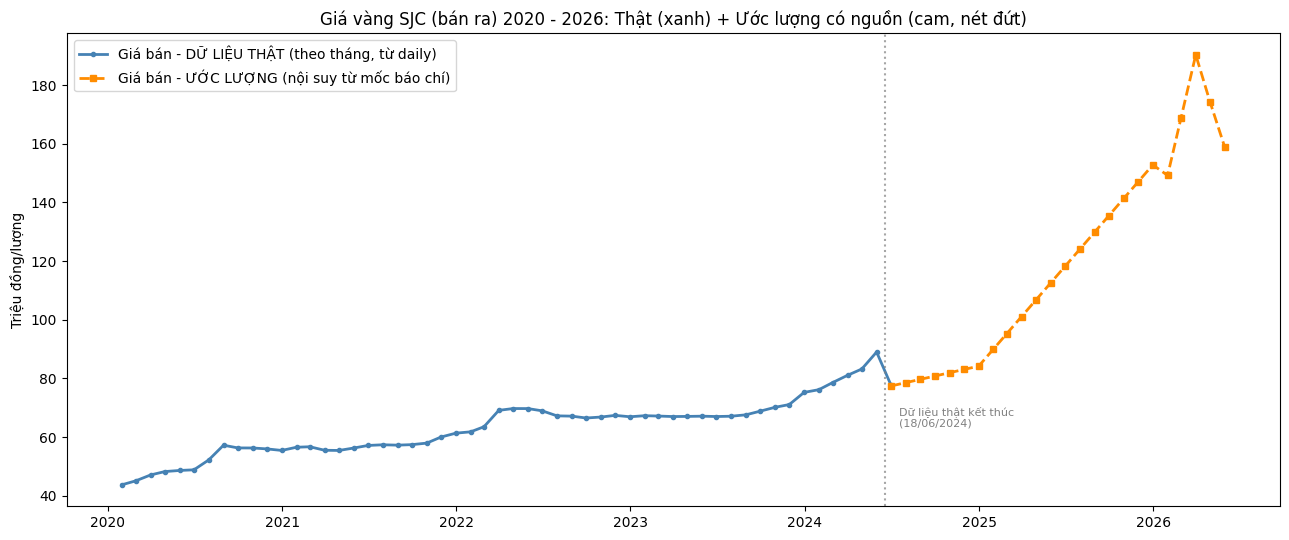

In [7]:
if supp is not None:
    fig, ax = plt.subplots(figsize=(13, 5.5))

    ax.plot(real_monthly.index, real_monthly["sell_price"], color="steelblue", lw=2,
            marker="o", markersize=3, label="Giá bán - DỮ LIỆU THẬT (theo tháng, từ daily)")
    ax.plot(est_monthly.index, est_monthly["sell_price"], color="darkorange", lw=2, ls="--",
            marker="s", markersize=4, label="Giá bán - ƯỚC LƯỢNG (nội suy từ mốc báo chí)")

    ax.axvline(df["date"].max(), color="gray", ls=":", alpha=0.7)
    ax.annotate(f"Dữ liệu thật kết thúc\n({df['date'].max().strftime('%d/%m/%Y')})",
                xy=(df["date"].max(), real_monthly["sell_price"].iloc[-1]),
                xytext=(10, -30), textcoords="offset points", fontsize=8, color="gray")

    ax.set_title(f"Giá vàng SJC (bán ra) {df['date'].min().year} - {est_monthly.index.max().year}: Thật (xanh) + Ước lượng có nguồn (cam, nét đứt)")
    ax.set_ylabel("Triệu đồng/lượng")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.savefig("output_extended_2020_2026.png", dpi=120)
    plt.show()


---
## Câu hỏi 1 — Xu hướng giá vàng SJC biến động như thế nào?

,mean,min,max
year,,,
2020,51.37,42.8,61.9
2021,57.46,54.5,61.9
2022,67.18,61.4,74.0
2023,68.63,66.5,79.6
2024,81.29,74.2,92.2


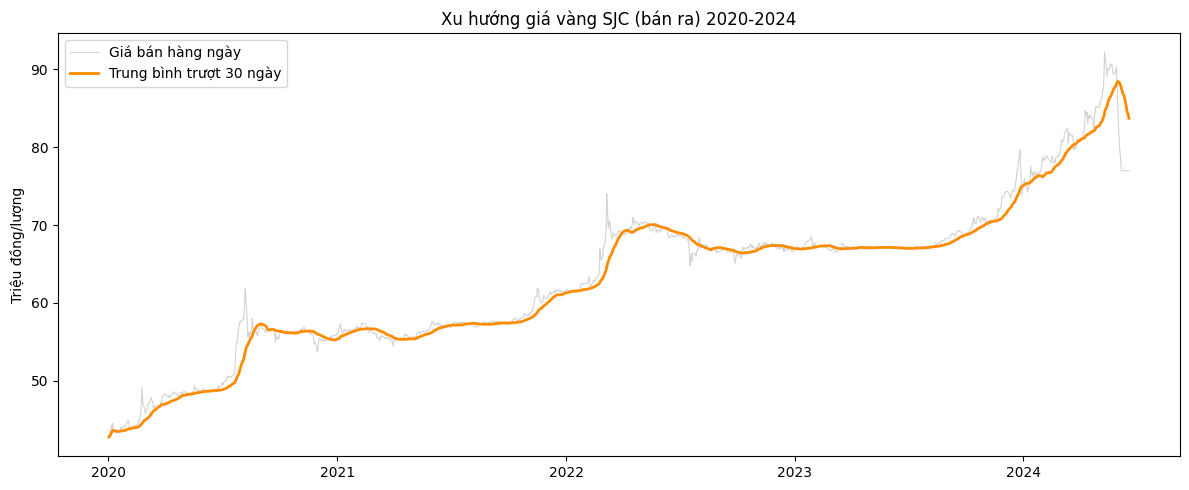

In [8]:
df["MA30"] = df["sell_price"].rolling(30, min_periods=1).mean()
yearly = df.groupby("year")["sell_price"].agg(["mean", "min", "max"]).round(2)
display(yearly)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["date"], df["sell_price"], color="lightgray", lw=0.8, label="Giá bán hàng ngày")
ax.plot(df["date"], df["MA30"], color="darkorange", lw=2, label="Trung bình trượt 30 ngày")
y0, y1 = df["date"].dt.year.min(), df["date"].dt.year.max()
ax.set_title(f"Xu hướng giá vàng SJC (bán ra) {y0}-{y1}")
ax.set_ylabel("Triệu đồng/lượng")
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.savefig("output_q1_trend.png", dpi=120)
plt.show()


---
## Câu hỏi 2 — Tháng nào giá vàng thường đạt đỉnh cao nhất / thấp nhất?

,mean_sell_price,max_sell_price,min_sell_price
month,,,
1,61.07,77.9,42.80
2,61.39,79.5,43.75
3,63.88,82.4,46.20
4,64.66,85.2,47.90
5,66.48,92.2,48.18
6,62.68,83.0,48.55
7,60.76,68.7,49.50
8,62.41,68.4,55.60
9,62.21,69.3,55.00


👉 Tháng có giá TB cao nhất: Tháng 5
👉 Tháng có giá TB thấp nhất: Tháng 7


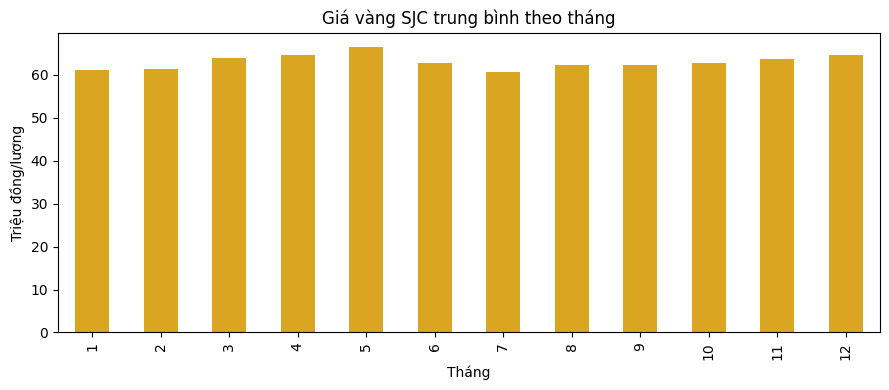

In [9]:
pivot = df.pivot_table(values="sell_price", index="month", aggfunc=["mean", "max", "min"])
pivot.columns = ["_".join(c) for c in pivot.columns]
pivot = pivot.round(2)
display(pivot)

top_month = pivot["mean_sell_price"].idxmax()
low_month = pivot["mean_sell_price"].idxmin()
print(f"👉 Tháng có giá TB cao nhất: Tháng {top_month}")
print(f"👉 Tháng có giá TB thấp nhất: Tháng {low_month}")

fig, ax = plt.subplots(figsize=(9, 4))
pivot["mean_sell_price"].plot(kind="bar", ax=ax, color="goldenrod")
ax.set_title("Giá vàng SJC trung bình theo tháng")
ax.set_ylabel("Triệu đồng/lượng")
ax.set_xlabel("Tháng")
plt.tight_layout()
plt.show()


---
## Câu hỏi 3 — Mức chênh lệch giá mua vào - bán ra qua các năm

,spread_TB,spread_MAX
year,,
2020,0.67,3.0
2021,0.61,1.2
2022,0.89,3.1
2023,0.75,3.9
2024,2.22,3.0


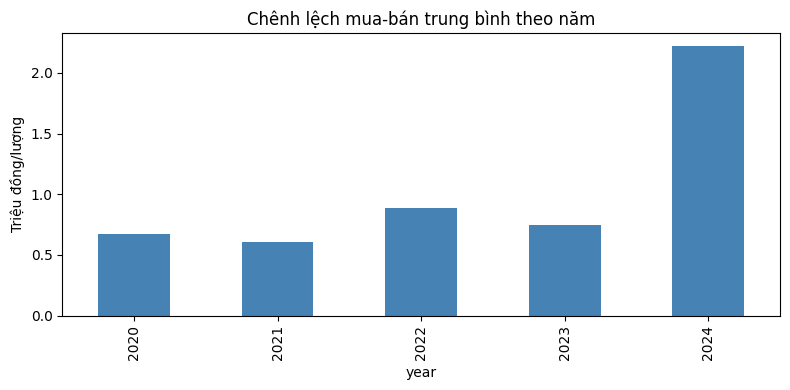

In [10]:
spread_yearly = df.groupby("year")["spread"].agg(["mean", "max"]).round(2)
spread_yearly.columns = ["spread_TB", "spread_MAX"]
display(spread_yearly)

fig, ax = plt.subplots(figsize=(8, 4))
spread_yearly["spread_TB"].plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Chênh lệch mua-bán trung bình theo năm")
ax.set_ylabel("Triệu đồng/lượng")
plt.tight_layout()
plt.show()


---
## Câu hỏi 4 — Sự kiện kinh tế - xã hội nào ảnh hưởng rõ rệt nhất?

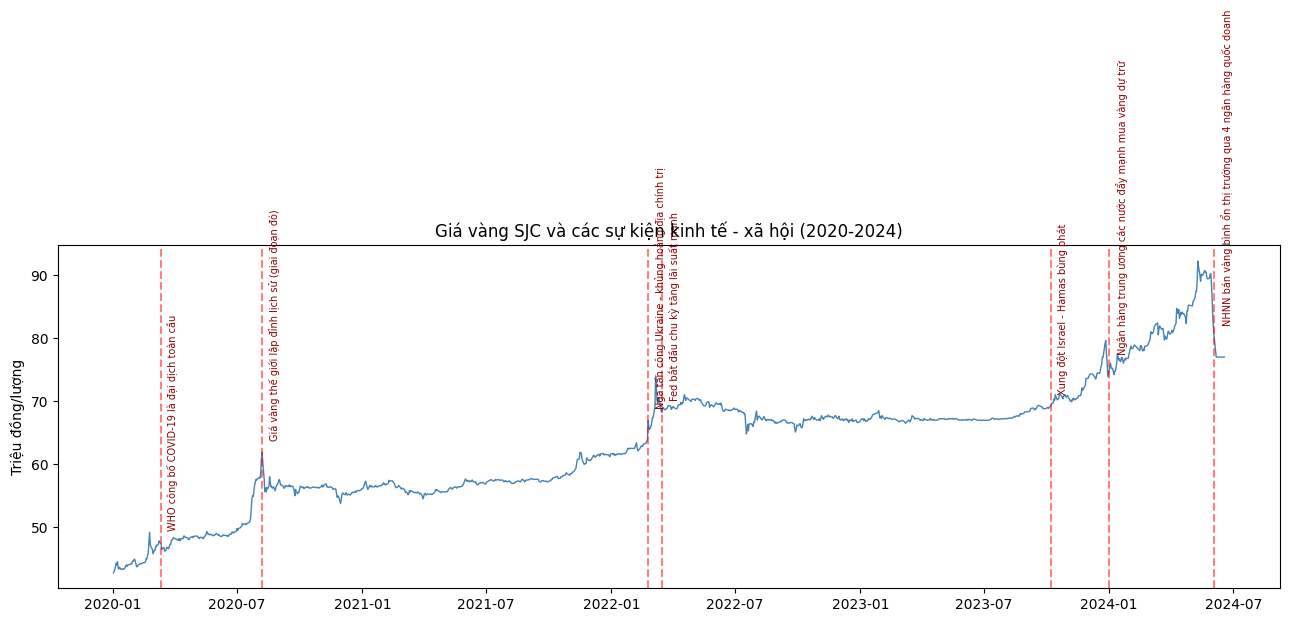

,Sự kiện,% thay đổi giá (30 ngày sau)
0,WHO công bố COVID-19 là đại dịch toàn cầu,-0.29
1,Giá vàng thế giới lập đỉnh lịch sử (giai đoạn đó),-8.35
2,Nga tấn công Ukraine - khủng hoảng địa chính trị,2.79
3,Fed bắt đầu chu kỳ tăng lãi suất mạnh,1.26
4,Xung đột Israel - Hamas bùng phát,1.84
5,Ngân hàng trung ương các nước đẩy mạnh mua vàn...,3.08
6,NHNN bán vàng bình ổn thị trường qua 4 ngân hà...,-3.46


In [11]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(df["date"], df["sell_price"], color="steelblue", lw=1)

impact_list = []
for date_str, label in EVENTS:
    d = pd.to_datetime(date_str)
    if df["date"].min() <= d <= df["date"].max():
        ax.axvline(d, color="red", ls="--", alpha=0.5)
        idx = (df["date"] - d).abs().idxmin()
        ax.annotate(label, xy=(d, df.loc[idx, "sell_price"]), xytext=(5, 10),
                    textcoords="offset points", fontsize=7, rotation=90, color="darkred")
        before = df.loc[df["date"] <= d, "sell_price"]
        after = df.loc[(df["date"] > d) & (df["date"] <= d + pd.Timedelta(days=30)), "sell_price"]
        if len(before) and len(after):
            pct = (after.mean() - before.iloc[-1]) / before.iloc[-1] * 100
            impact_list.append((label, round(pct, 2)))

ax.set_title(f"Giá vàng SJC và các sự kiện kinh tế - xã hội ({df['date'].dt.year.min()}-{df['date'].dt.year.max()})")
ax.set_ylabel("Triệu đồng/lượng")
plt.tight_layout()
plt.savefig("output_q4_events.png", dpi=120)
plt.show()

impact_df = pd.DataFrame(impact_list, columns=["Sự kiện", "% thay đổi giá (30 ngày sau)"])
display(impact_df)


---
## Câu hỏi 5 — Mô hình nào (Linear Regression, ARIMA...) dự đoán chính xác nhất?

c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


So sánh sai số trên tập kiểm tra (10% dữ liệu cuối):
  Linear Regression    | RMSE = 7.418 | MAE = 6.255
  ARIMA                | RMSE = 6.163 | MAE = 4.911

👉 Mô hình có độ chính xác cao nhất: ARIMA


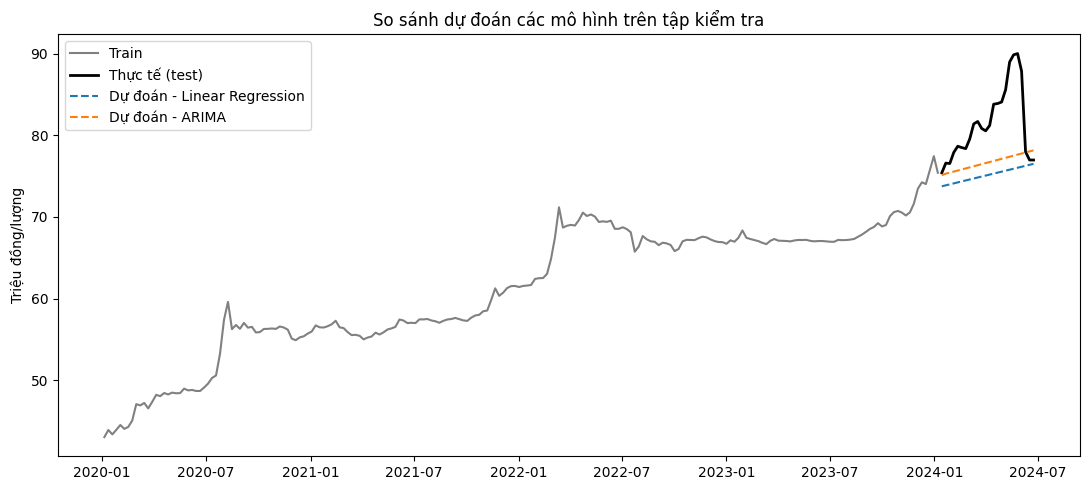

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

series = df.set_index("date")["sell_price"].resample("W").mean().dropna()
train_size = int(len(series) * 0.9)
train, test = series.iloc[:train_size], series.iloc[train_size:]

results = {}

X_train = np.arange(len(train)).reshape(-1, 1)
X_test = np.arange(len(train), len(train) + len(test)).reshape(-1, 1)
lr = LinearRegression().fit(X_train, train.values)
pred_lr = lr.predict(X_test)
results["Linear Regression"] = {
    "RMSE": np.sqrt(mean_squared_error(test.values, pred_lr)),
    "MAE": mean_absolute_error(test.values, pred_lr),
    "model": lr,
}

try:
    from statsmodels.tsa.arima.model import ARIMA
    arima_fit = ARIMA(train, order=(2, 1, 2)).fit()
    pred_arima = arima_fit.forecast(steps=len(test))
    results["ARIMA"] = {
        "RMSE": np.sqrt(mean_squared_error(test.values, pred_arima)),
        "MAE": mean_absolute_error(test.values, pred_arima),
        "model": arima_fit,
    }
except ImportError:
    print("⚠️  Chưa cài statsmodels -> bỏ qua ARIMA. Chạy: pip install statsmodels rồi chạy lại cell này.")

print("So sánh sai số trên tập kiểm tra (10% dữ liệu cuối):")
for name, r in results.items():
    print(f"  {name:20s} | RMSE = {r['RMSE']:.3f} | MAE = {r['MAE']:.3f}")

best_model_name = min(results, key=lambda k: results[k]["RMSE"])
print(f"\n👉 Mô hình có độ chính xác cao nhất: {best_model_name}")

# Biểu đồ so sánh dự đoán vs thực tế
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(train.index, train.values, label="Train", color="gray")
ax.plot(test.index, test.values, label="Thực tế (test)", color="black", lw=2)
ax.plot(test.index, pred_lr, label="Dự đoán - Linear Regression", ls="--")
if "ARIMA" in results:
    ax.plot(test.index, pred_arima, label="Dự đoán - ARIMA", ls="--")
ax.legend()
ax.set_title("So sánh dự đoán các mô hình trên tập kiểm tra")
ax.set_ylabel("Triệu đồng/lượng")
plt.tight_layout()
plt.show()


---
## Câu hỏi bổ sung 1 — Dự đoán giá vàng SJC vào tuần/tháng tiếp theo

In [13]:
steps = 4  # số tuần muốn dự đoán tới

if best_model_name == "Linear Regression":
    model = results["Linear Regression"]["model"]
    X_future = np.arange(len(series), len(series) + steps).reshape(-1, 1)
    forecast = model.predict(X_future)
else:
    forecast = results["ARIMA"]["model"].forecast(steps=steps).values

future_dates = pd.date_range(series.index[-1] + pd.Timedelta(weeks=1), periods=steps, freq="W")
forecast_df = pd.DataFrame({"date": future_dates, "du_doan_gia_trieu_dong": np.round(forecast, 2)})
display(forecast_df)


,date,du_doan_gia_trieu_dong
0,2024-06-30,75.11
1,2024-07-07,75.31
2,2024-07-14,75.43
3,2024-07-21,75.56


---
## Câu hỏi bổ sung 2 — Phân cụm các giai đoạn giá vàng (tăng mạnh / ổn định / giảm)

,pct_change,volatility,nhan_giai_doan
date,,,
2023-07-31,0.15,0.18,Ổn định
2023-08-31,0.71,0.45,Ổn định
2023-09-30,1.85,0.86,Ổn định
2023-10-31,1.90,0.67,Ổn định
2023-11-30,1.35,0.30,Ổn định
2023-12-31,5.82,2.44,Tăng mạnh
2024-01-31,1.23,2.62,Ổn định
2024-02-29,3.20,2.30,Ổn định
2024-03-31,3.13,1.11,Ổn định



Số tháng thuộc mỗi giai đoạn:
nhan_giai_doan
Ổn định              48
Tăng mạnh             5
Giảm / Điều chỉnh     1
Name: count, dtype: int64


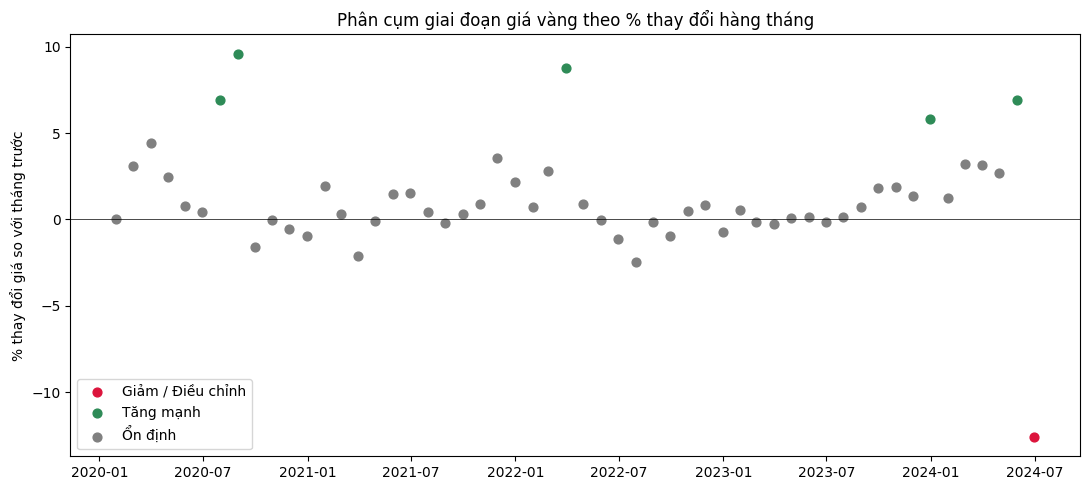

In [14]:
from sklearn.cluster import KMeans

monthly = df.set_index("date")["sell_price"].resample("ME").mean()
pct_change = monthly.pct_change().fillna(0) * 100
volatility = monthly.pct_change().rolling(3).std().fillna(0) * 100

features = pd.DataFrame({"pct_change": pct_change, "volatility": volatility})
km = KMeans(n_clusters=3, random_state=42, n_init=10)
features["cluster_id"] = km.fit_predict(features[["pct_change", "volatility"]])

cluster_order = features.groupby("cluster_id")["pct_change"].mean().sort_values().index
labels_order = ["Giảm / Điều chỉnh", "Ổn định", "Tăng mạnh"]
label_map = {cid: labels_order[i] for i, cid in enumerate(cluster_order)}
features["nhan_giai_doan"] = features["cluster_id"].map(label_map)

display(features[["pct_change", "volatility", "nhan_giai_doan"]].round(2).tail(12))
print("\nSố tháng thuộc mỗi giai đoạn:")
print(features["nhan_giai_doan"].value_counts())

fig, ax = plt.subplots(figsize=(11, 5))
colors = {"Giảm / Điều chỉnh": "crimson", "Ổn định": "gray", "Tăng mạnh": "seagreen"}
for label, group in features.groupby("nhan_giai_doan"):
    ax.scatter(group.index, group["pct_change"], label=label, color=colors.get(label), s=40)
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Phân cụm giai đoạn giá vàng theo % thay đổi hàng tháng")
ax.set_ylabel("% thay đổi giá so với tháng trước")
ax.legend()
plt.tight_layout()
plt.show()


---
## Tổng kết

Điền các nhận định chính vào đây để đưa sang báo cáo Word / slide PowerPoint:

- Câu 1: ...
- Câu 2: ...
- Câu 3: ...
- Câu 4: ...
- Câu 5: ...
- Dự đoán: ...
- Phân cụm: ...